In [2]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
demo = pd.read_csv("dta\\DEMO_J.csv")
hepatitis_a = pd.read_csv("dta\\HEPA_J.csv")
hepatitis_b = pd.read_csv("dta\\HEPB_S_J.csv")
# atc_vih = pd.read_csv("dta\\ANTICUERPO_VIH.csv")
colesterol_total = pd.read_csv("dta\\COLESTEROL_TOTAL.csv")
hierro = pd.read_csv("dta\\HIERRO.csv")
insulina = pd.read_csv("dta\\INSULINA.csv")
presion_sanguinea = pd.read_csv("dta\\PRESION_SANGUINEA.csv")
trigliceridos = pd.read_csv("dta\\TRIGLICERIDOS.csv")
vitamina_a_e = pd.read_csv("dta\\VITAMINA_A_E.csv")

In [3]:
# Diccionario de renombramiento
columnas_deseadas = [
    "SEQN",
    "RIAGENDR",
    "RIDAGEYR",
    "RIDRETH3",
    "INDFMPIR"
]
demo = demo[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXTR",
    "LBDLDL",
    "LBDLDLM",
    "LBDLDLN"
]
trigliceridos = trigliceridos[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXHA",
]
hepatitis_a = hepatitis_a[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXHBS"
]
hepatitis_b = hepatitis_b[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXTC"
]
colesterol_total = colesterol_total[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXFER"
]
hierro = hierro[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXIN"
]
insulina = insulina[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "BPXPLS",
    "BPXPULS",
    "BPXPTY"
]
presion_sanguinea = presion_sanguinea[columnas_deseadas].copy()

columnas_deseadas = [
    "SEQN",
    "LBXVIA",
    "LBXVIE",
    "LBXLUZ",
    "LBXLCC",
    "LBXBEC"
]
vitamina_a_e = vitamina_a_e[columnas_deseadas].copy()

# columnas_deseadas = [
#     "SEQN",
#     "LBXHIVC"
# ]
# atc_vih = atc_vih[columnas_deseadas].copy()

In [4]:
# Aplica un inner join sucesivo sobre 'SEQN'
df_merged = pd.merge(demo, hepatitis_a, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, hepatitis_b, on='SEQN', how='inner')
# df_merged = pd.merge(df_merged, atc_vih, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, colesterol_total, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, hierro, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, insulina, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, presion_sanguinea, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, trigliceridos, on='SEQN', how='inner')
df_merged = pd.merge(df_merged, vitamina_a_e, on='SEQN', how='inner')

df_merged.to_csv('datos.csv', index=False)

In [5]:
df = pd.read_csv('datos.csv')

# Variables categoricas
df['BPXPULS'] = df['BPXPULS'].astype('category')
df['LBXHA'] = df['LBXHA'].astype('category')
df['LBXHBS'] = df['LBXHBS'].astype('category')
df['BPXPTY'] = df['BPXPTY'].astype('category')



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   SEQN      2060 non-null   int64   
 1   RIAGENDR  2060 non-null   int64   
 2   RIDAGEYR  2060 non-null   int64   
 3   RIDRETH3  2060 non-null   int64   
 4   INDFMPIR  1786 non-null   float64 
 5   LBXHA     1911 non-null   category
 6   LBXHBS    1944 non-null   category
 7   LBXTC     1932 non-null   float64 
 8   LBXFER    1958 non-null   float64 
 9   LBXIN     1924 non-null   float64 
 10  BPXPLS    1967 non-null   float64 
 11  BPXPULS   1967 non-null   category
 12  BPXPTY    1967 non-null   category
 13  LBXTR     1929 non-null   float64 
 14  LBDLDL    1910 non-null   float64 
 15  LBDLDLM   1910 non-null   float64 
 16  LBDLDLN   1924 non-null   float64 
 17  LBXVIA    1952 non-null   float64 
 18  LBXVIE    1911 non-null   float64 
 19  LBXLUZ    1885 non-null   float64 
 20  LBXLCC  

In [ ]:
from funtions import imputar_datos, graficas_generales, analizar_distribucion, graficar_variables_categoricas, graficar_relacion, graficar_categorica_vs_continua, clasificar_insulina, anova_con_terciles, permutacion_correlacion, permutacion_diferencia_medias
    
df = imputar_datos(df)
df = df.copy()
# Para entrenar es mejor
df['BPXPULS'] = df['BPXPULS'].astype('int64')
df['LBXHA'] = df['LBXHA'].astype('int64')
df['LBXHBS'] = df['LBXHBS'].astype('int64')
df['BPXPTY'] = df['BPXPTY'].astype('int64')

d:\programacion_esta\proyecto\proyecto-dreamteamproject\funtions.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode().iloc[0], inplace=True)


#### Estadistica descriptiva:

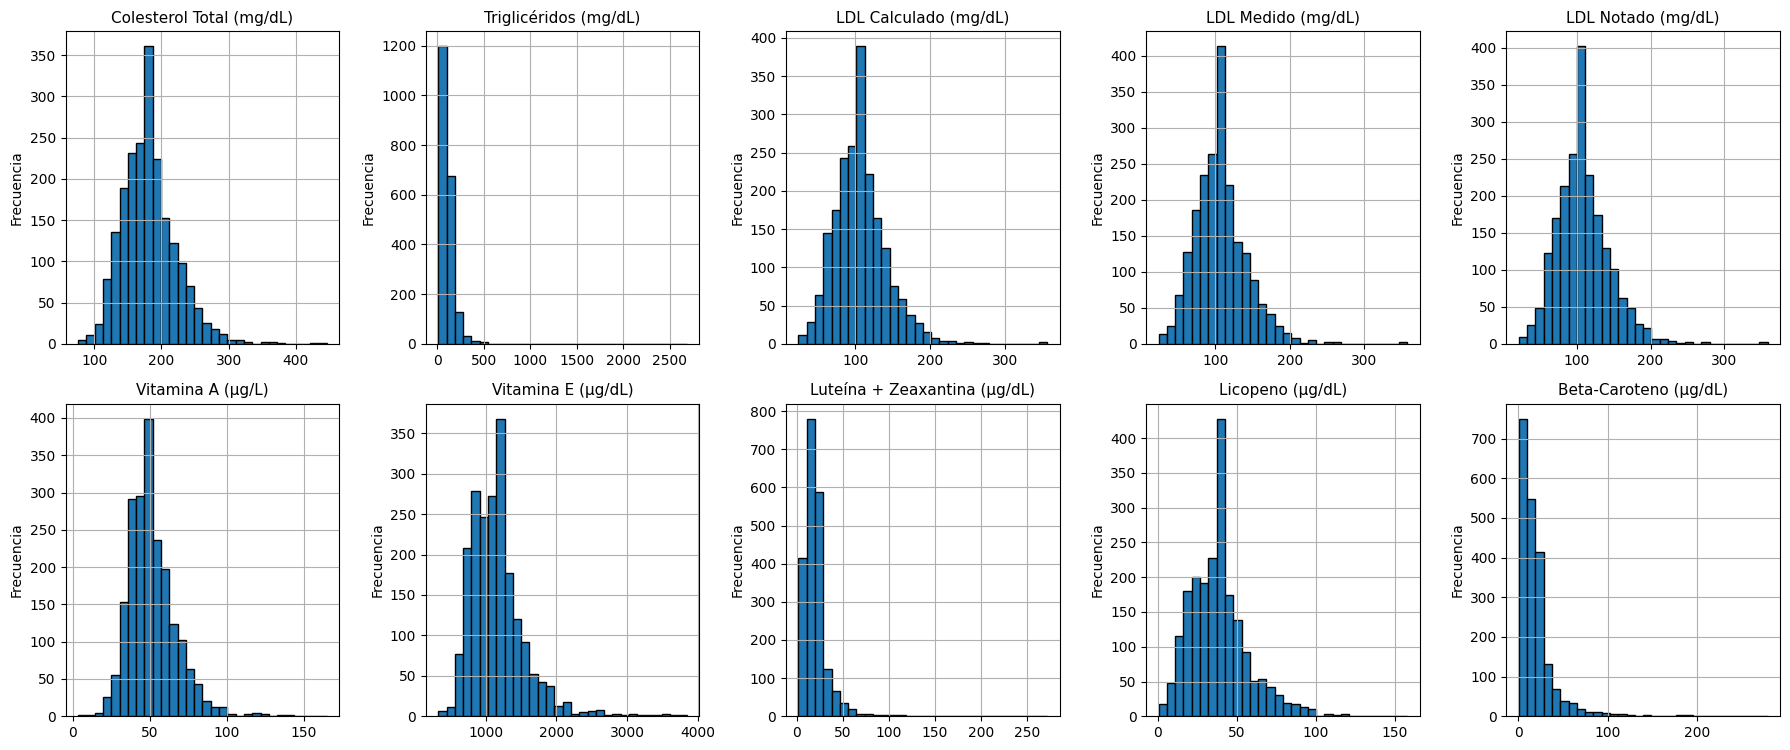

In [8]:
# Diccionario con nombres descriptivos
nombres_variables = {
    'LBXTC': 'Colesterol Total (mg/dL)',
    'LBXTR': 'Triglicéridos (mg/dL)',
    'LBDLDL': 'LDL Calculado (mg/dL)',
    'LBDLDLM': 'LDL Medido (mg/dL)',
    'LBDLDLN': 'LDL Notado (mg/dL)',
    'LBXVIA': 'Vitamina A (μg/L)',
    'LBXVIE': 'Vitamina E (μg/dL)',
    'LBXLUZ': 'Luteína + Zeaxantina (μg/dL)',
    'LBXLCC': 'Licopeno (μg/dL)',
    'LBXBEC': 'Beta-Caroteno (μg/dL)',
    'LBXFER': 'Hierro en suero (μg/dL)',
    'LBXIN': 'Insulina (μU/mL)',
    'BPXPLS': 'Pulso en reposo 1 (lpm)',
    'BPXPULS': 'Pulso en reposo 2 (lpm)',
    'BPXPTY': 'Tipo de pulso (código)',
    'LBXHA': 'Hepatitis A (Anticuerpos)',
    'LBXHBS': 'Hepatitis B (Anticuerpos)',
    'LBXHIVC': 'VIH Confirmado',
    'RIAGENDR': 'Sexo',
    'RIDAGEYR': 'Edad (años)',
    'RIDRETH3': 'Raza / Etnicidad',
    'INDFMPIR': 'Índice de pobreza (PIR)',
}


nombres_variables_continuas = {
    'LBXTC': 'Colesterol Total (mg/dL)',
    'LBXTR': 'Triglicéridos (mg/dL)',
    'LBDLDL': 'LDL Calculado (mg/dL)',
    'LBDLDLM': 'LDL Medido (mg/dL)',
    'LBDLDLN': 'LDL Notado (mg/dL)',
    'LBXVIA': 'Vitamina A (μg/L)',
    'LBXVIE': 'Vitamina E (μg/dL)',
    'LBXLUZ': 'Luteína + Zeaxantina (μg/dL)',
    'LBXLCC': 'Licopeno (μg/dL)',
    'LBXBEC': 'Beta-Caroteno (μg/dL)',
    'LBXFER': 'Hierro en suero (μg/dL)',
    'LBXIN': 'Insulina (μU/mL)',
    'BPXPLS': 'Pulso en reposo 1 (lpm)',
    'BPXPULS': 'Pulso en reposo 2 (lpm)',
    'INDFMPIR': 'Índice de pobreza (PIR)',
    'RIDAGEYR': 'Edad (años)'
}

nombres_variables_categoricas = {
    'RIAGENDR': 'Sexo',
    'RIDRETH3': 'Raza / Etnicidad',
    'LBXHA': 'Hepatitis A (Anticuerpos)',
    'LBXHBS': 'Hepatitis B (Anticuerpos)'
}



graficas_generales(df, nombres_variables=nombres_variables_continuas)

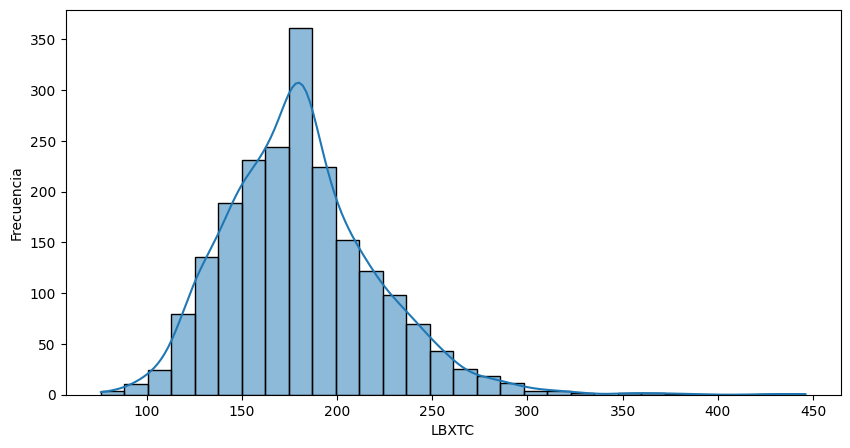

Shapiro-Wilk p-value: 0.00000 (No Normal)

Resultados KS para diferentes distribuciones:
lognorm: KS p-value = 0.00635
beta: KS p-value = 0.00455
gamma: KS p-value = 0.00282
norm: KS p-value = 0.00000
expon: KS p-value = 0.00000


c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\scipy\stats\_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\scipy\stats\_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


In [ ]:
analizar_distribucion(df, 'LBXTC')

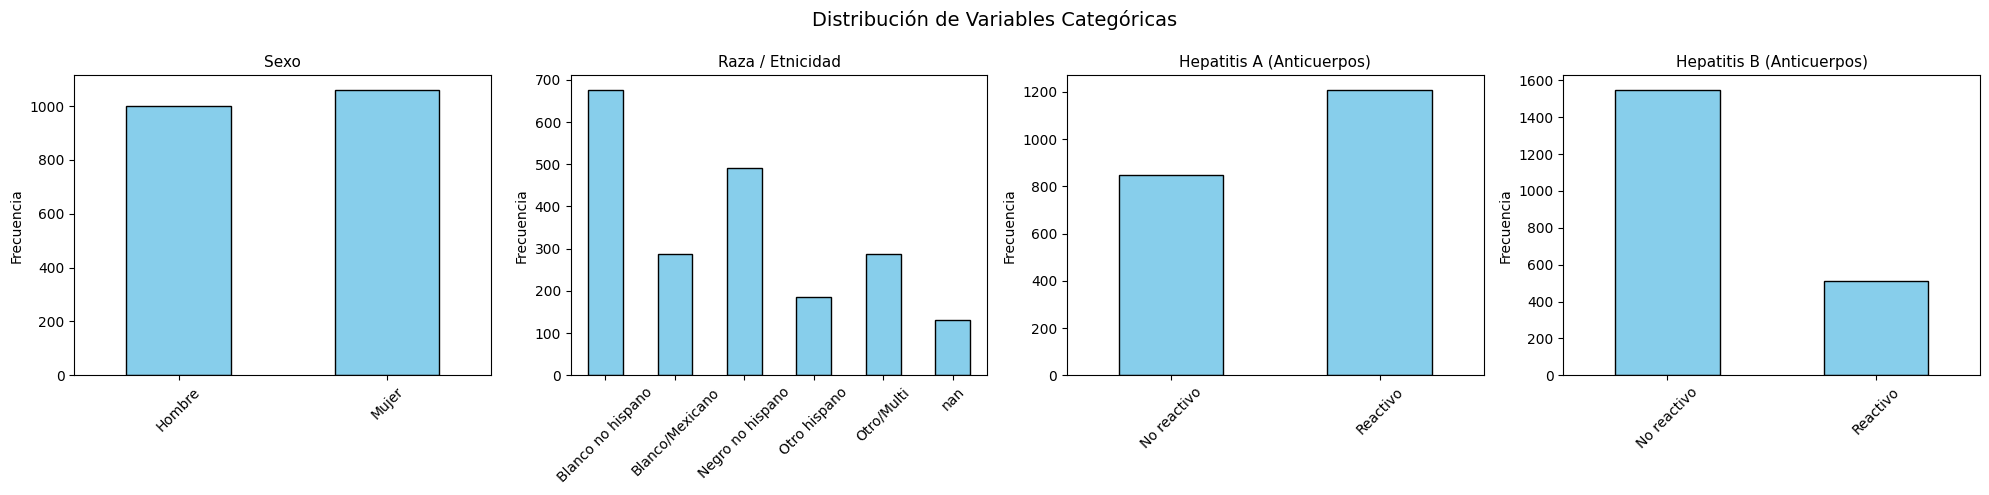

In [10]:

# Diccionario de etiquetas por variable
etiquetas_categoricas = {
    'RIAGENDR': {1: 'Hombre', 2: 'Mujer'},
    'RIDRETH3': {
        1: 'Blanco/Mexicano',
        2: 'Otro hispano',
        3: 'Blanco no hispano',
        4: 'Negro no hispano',
        6: 'Otro/Multi'
    },
    'LBXHA': {1: 'Reactivo', 2: 'No reactivo'},
    'LBXHBS': {1: 'Reactivo', 2: 'No reactivo'}
}

graficar_variables_categoricas(df, nombres_variables_categoricas, etiquetas_categoricas)


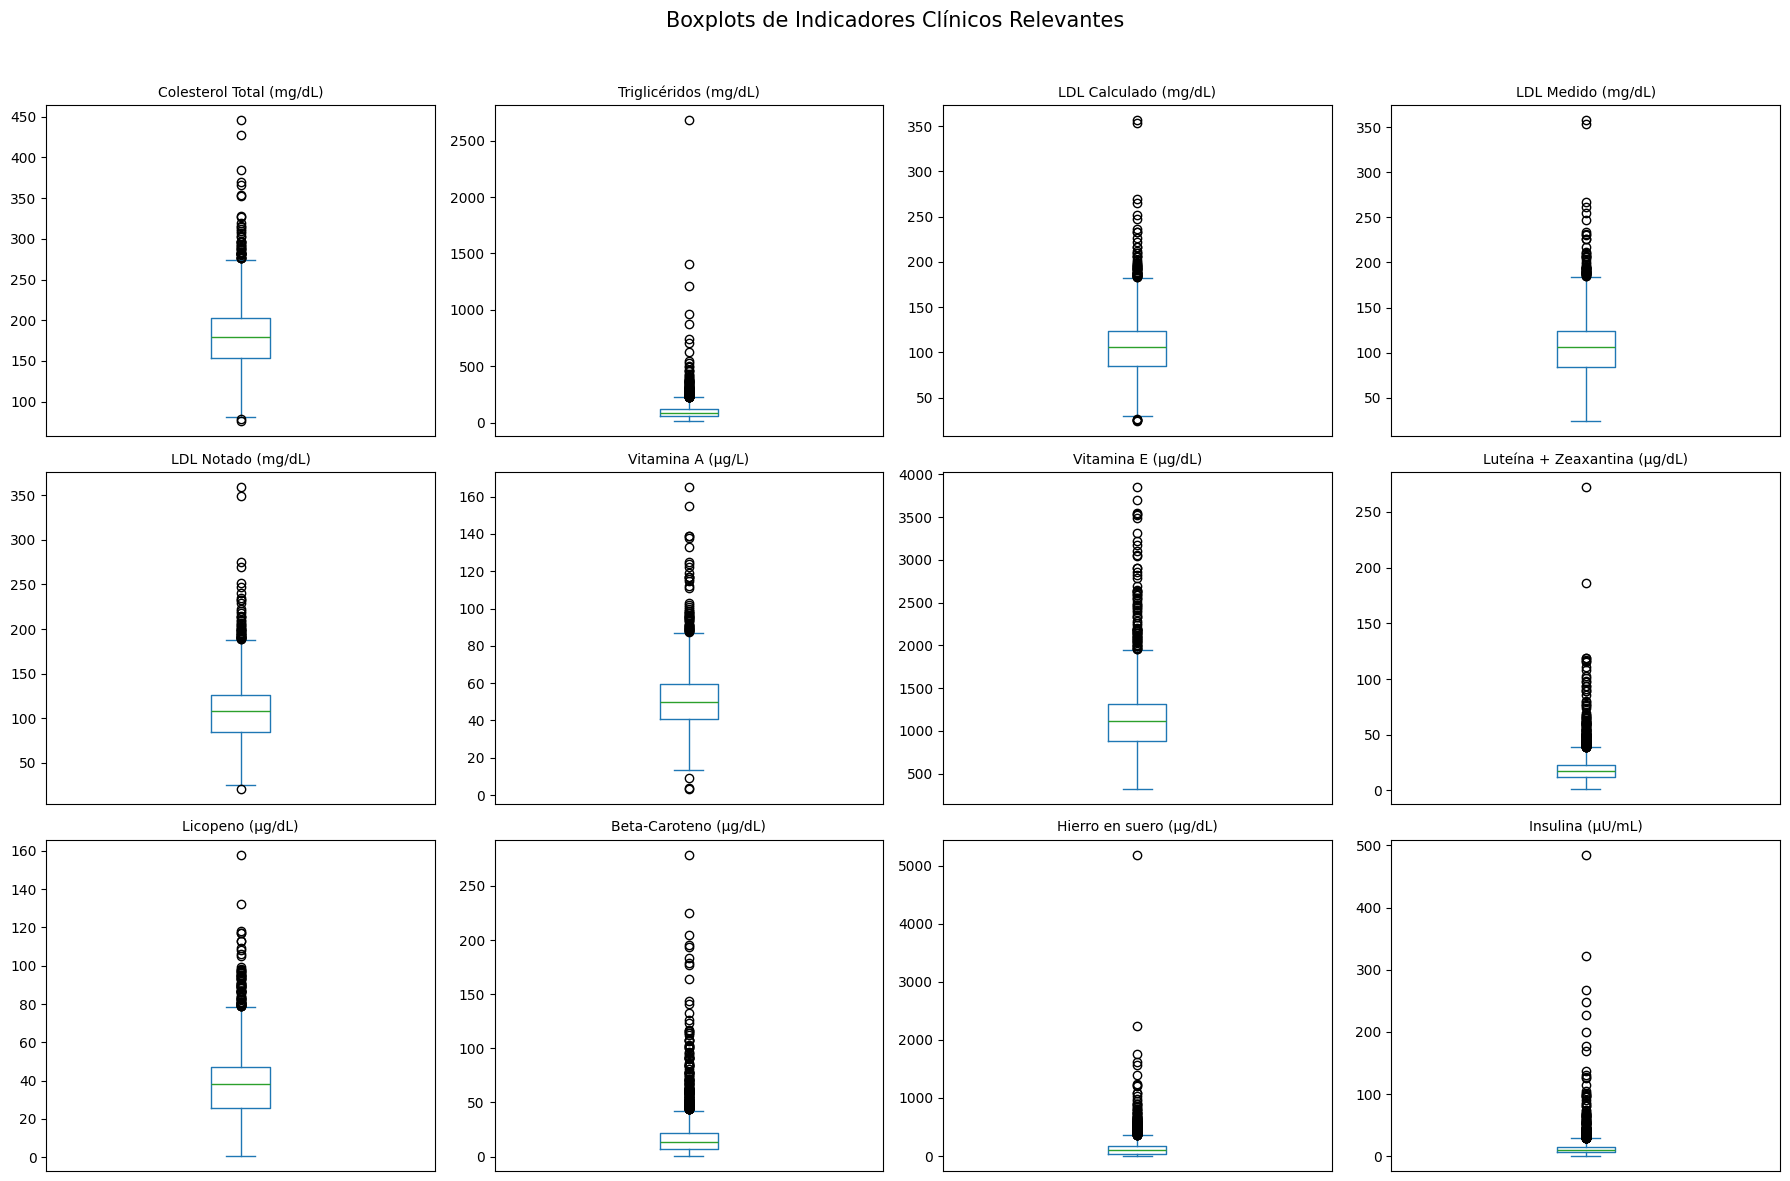

In [11]:
variables_boxplot = list(nombres_variables.keys())

# Crear figura y ejes
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for ax, var in zip(axes, variables_boxplot):
    df[var].plot(kind='box', ax=ax, vert=True)
    ax.set_title(nombres_variables[var], fontsize=10)
    ax.set_ylabel('')
    ax.set_xticks([]) 

# Eliminar ejes vacíos si sobran
for i in range(len(variables_boxplot), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Boxplots de Indicadores Clínicos Relevantes', fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


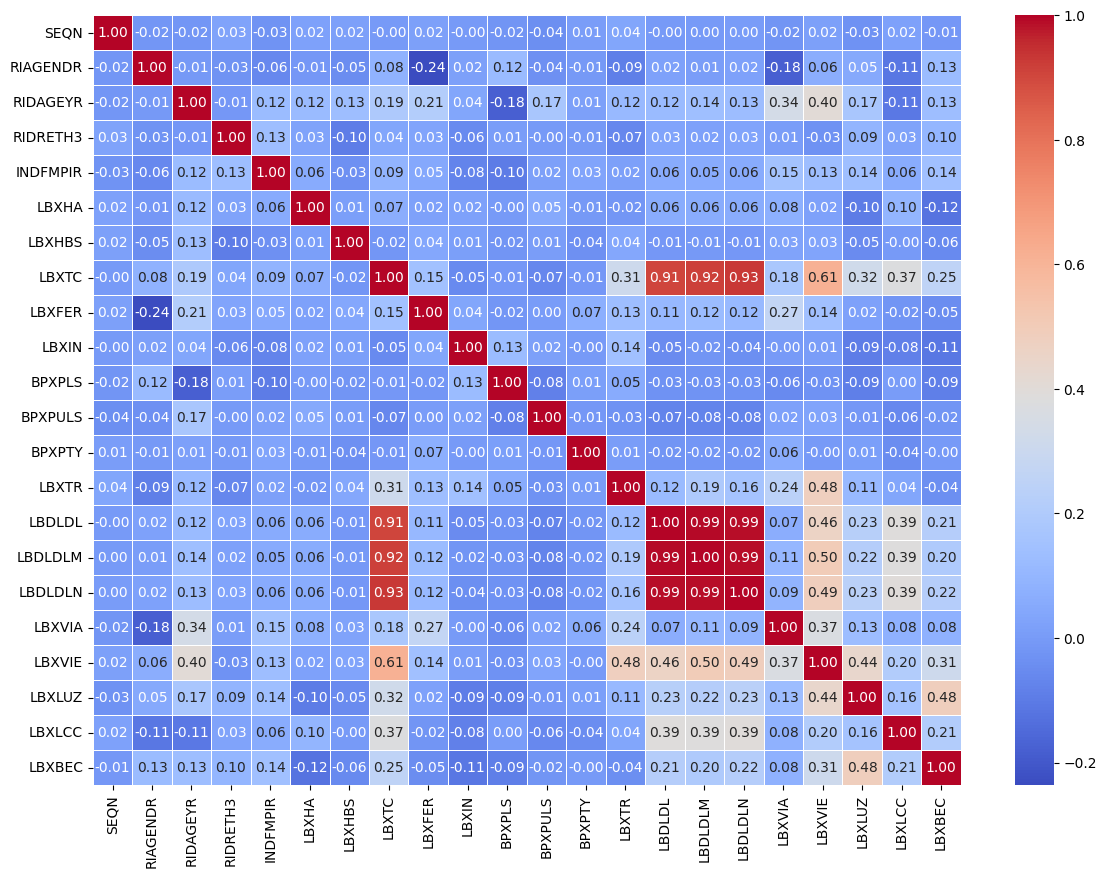

In [12]:
# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcular matriz de correlación
corr = df_numeric.corr()

# Mostrar como mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()


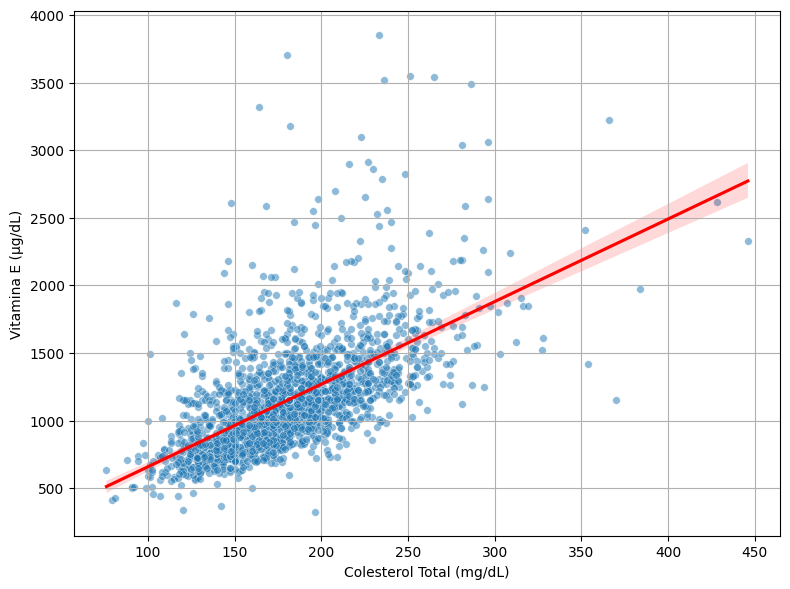

In [ ]:
graficar_relacion(df, 'LBXTC', 'LBXVIE', nombres_legibles=nombres_variables_continuas)


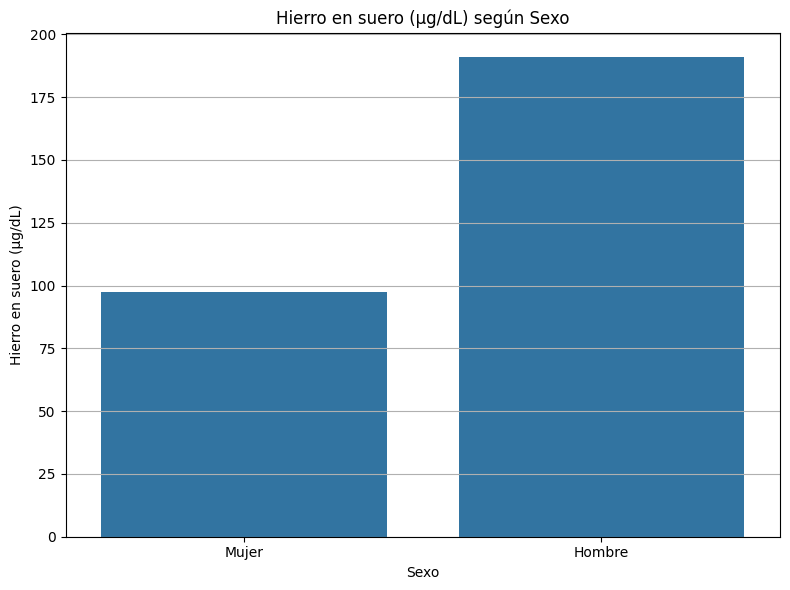

In [18]:
graficar_categorica_vs_continua(
    df,
    var_cat='RIAGENDR',
    var_num='LBXFER',
    etiquetas=etiquetas_categoricas,
    nombres_legibles=nombres_variables,
    tipo='bar'  # Cambia a 'violin' o 'bar'
)


In [14]:

df_limpio = df.copy()


df_limpio['INS_CLASI'] = df_limpio['LBXIN'].apply(clasificar_insulina)


variables_binarias = {
    'Hepatitis A': 'LBXHA',
    'Hepatitis B': 'LBXHBS'
}
variables_continuas = {
    'Colesterol total': 'LBXTC',
    'LDL medido': 'LBDLDLM',
    'Triglicéridos': 'LBXTR',
    'Hierro sérico': 'LBXFER',
    'Vitamina A': 'LBXVIA',
    'Vitamina E': 'LBXVIE',
    'Criptoxantina (Luteína/Zeaxantina)': 'LBXLUZ',
    'Beta-caroteno': 'LBXBEC',
    'Licopeno': 'LBXLCC'
}


# Ejecutar análisis
anova_con_terciles(df_limpio, variables_continuas)
permutacion_correlacion(df_limpio, variables_continuas)
permutacion_diferencia_medias(df_limpio, variables_binarias)



ANÁLISIS ANOVA (INSULINA TERCILES vs VARIABLES CONTINUAS):

Colesterol total (LBXTC): F = 5.897, p = 0.0028
LDL medido (LBDLDLM): F = 3.506, p = 0.0302
Triglicéridos (LBXTR): F = 20.110, p = 0.0000
Hierro sérico (LBXFER): F = 0.315, p = 0.7295
Vitamina A (LBXVIA): F = 0.644, p = 0.5253
Vitamina E (LBXVIE): F = 0.948, p = 0.3879
Criptoxantina (Luteína/Zeaxantina) (LBXLUZ): F = 16.565, p = 0.0000
Beta-caroteno (LBXBEC): F = 21.755, p = 0.0000
Licopeno (LBXLCC): F = 10.297, p = 0.0000

PRUEBAS DE PERMUTACIÓN PARA CORRELACIONES:

Colesterol total (LBXTC): Corr = -0.053, p_perm = 0.0166
LDL medido (LBDLDLM): Corr = -0.022, p_perm = 0.3067
Triglicéridos (LBXTR): Corr = 0.143, p_perm = 0.0020
Hierro sérico (LBXFER): Corr = 0.037, p_perm = 0.0543
Vitamina A (LBXVIA): Corr = -0.004, p_perm = 0.8401
Vitamina E (LBXVIE): Corr = 0.008, p_perm = 0.6896
Criptoxantina (Luteína/Zeaxantina) (LBXLUZ): Corr = -0.094, p_perm = 0.0029
Beta-caroteno (LBXBEC): Corr = -0.114, p_perm = 0.0010
Licopeno (LBXLCC

In [10]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [11]:
import pandas as pd
df_limpio = pd.read_csv('dta_train/dta_train.csv')

In [12]:
def clasificar_insulina(valor):
    if valor == "Aves":
        return int(0)  # Normal
    elif valor == "Insecta":
        return int(1)  # Resistencia a la insulina
    elif valor == "Amphibia":
        return int(2)  #Ddiabetes tipo 2
    else:
        return int(3)

# df_limpio['INS_CLASI'] = df_limpio['LBXIN'].apply(clasificar_insulina)


In [13]:
df_limpio['class_name'] = df_limpio['class_name'].apply(clasificar_insulina)

In [ ]:
# Separar datos
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


X = df_limpio.drop(columns=['class_name', 'is_aves','is_amphibia', 'is_insecta', 'is_mammalia'])
X = X.dropna()
y = df_limpio['class_name']
y = y.loc[X.index]  # mismos índices que X


# Dividir antes de aplicar SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train) # type: ignore


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled) # type: ignore
X_test_scaled = scaler.transform(X_test)

from collections import Counter
print("Distribución después de SMOTE:", Counter(y_train_resampled))

# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=100,
#         max_depth=10,                 
#         min_samples_leaf=5,          
#         random_state=42
#     ),
#     "XGBoost": XGBClassifier(
#         eval_metric='logloss',
#         reg_alpha=0.5,               # L1 regularización
#         reg_lambda=1.0,              # L2 regularización
#         max_depth=6,
#         learning_rate=0.1,
#         n_estimators=100,
#         random_state=42
#     ),
#     "Logistic Regression": LogisticRegression(
#         penalty='l2',                # L2 regularización (ridge)
#         C=0.5,                       # menor C => más regularización
#         solver='liblinear',
#         max_iter=1000,
#         random_state=42
#     ),
#     "SVM": SVC(
#         kernel='rbf',
#         C=0.5,                       # menor C => más margen, menos sobreajuste
#         probability=True,
#         random_state=42
#     )
# }

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=50,
        min_samples_leaf=1,
        min_samples_split= 4,
        max_features= 0.5,
        class_weight= "balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        reg_alpha=0.0012594902151627182,                 # L1 regularización
        reg_lambda= 3.3379302017839375e-08,              # L2 regularización
        max_depth=6,
        learning_rate=0.2380595323906636,
        n_estimators=250,
        subsample= 0.90953130925455,
        colsample_bytree= 0.8406641771643899,
        gamma= 0.34093204951547396,
        min_child_weight=8,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        penalty='elasticnet',                      # L2 regularización (ridge)
        C=2.802097377064016,                       # menor C => más regularización
        solver='saga',                             # Changed solver to 'saga' for elasticnet compatibility
        l1_ratio= 0.7220956731371371,
        max_iter=1000,
        random_state=42
    ),
    "SVM": SVC(
        kernel='rbf',
        C=140.83016772042197,                       # menor C => más margen, menos sobreajuste
        probability=True,
        random_state=42,
        gamma= "auto",
        class_weight= None,
        tol= 0.00010347304126348677
    ),
}

Distribución después de SMOTE: Counter({2: 5162, 0: 5162, 1: 5162, 3: 5162})


In [17]:
resultados = []

def evaluar(nombre, y_test, y_pred, y_proba):
    resultados.append({
        'Modelo': nombre,
        'Precision': round(float(precision_score(y_test, y_pred, average='weighted')), 4),
        'Recall': round(float(recall_score(y_test, y_pred, average='weighted')), 4),
        'F1-Score': round(float(f1_score(y_test, y_pred, average='weighted')), 4),
        'AUC': round(float(roc_auc_score(y_test, y_proba, multi_class='ovr')), 4)
    })


for nombre, modelo in models.items():
    if nombre in ['Logistic Regression', 'SVM']:
        modelo.fit(X_train_resampled, y_train_resampled)
        y_predic = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)
    else:
        modelo.fit(X_train_resampled, y_train_resampled)
        y_predic = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)
    evaluar(nombre, y_test, y_predic, y_proba)
  
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


                Modelo  Precision  Recall  F1-Score     AUC
0        Random Forest     0.9335  0.9315    0.9320  0.9899
1              XGBoost     0.9238  0.9239    0.9236  0.9899
2  Logistic Regression     0.3661  0.3517    0.3224  0.5426
3                  SVM     0.1807  0.4251    0.2536  0.5000


c:\Users\overm\miniconda3\envs\PLE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


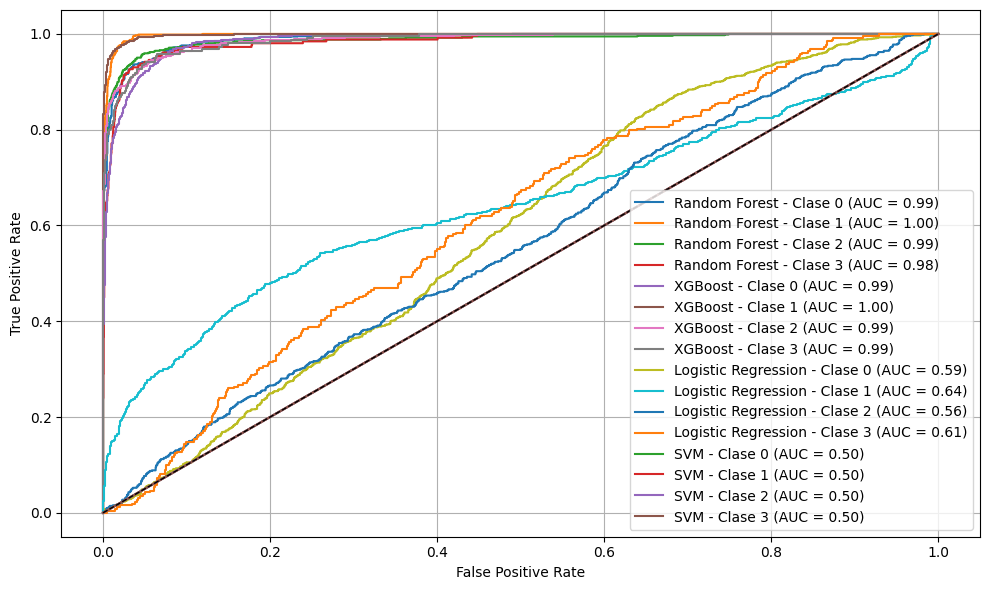

In [18]:
# Número de clases
clases = sorted(np.unique(y_test)) 
n_classes = len(clases)

# Binarizar las etiquetas de y_test (One-hot)
y_test_bin = label_binarize(y_test, classes=clases)

plt.figure(figsize=(10, 6))

for nombre, modelo in models.items():
    y_proba = modelo.predict_proba(X_test)  # (n_samples, n_classes)
 
    # Curva ROC para cada clase
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])  # type: ignore
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{nombre} - Clase {i} (AUC = {roc_auc:.2f})")

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Curvas ROC por clase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Calculando SHAP para XGBoos


100%|===================| 12114/12148 [04:37<00:00]        

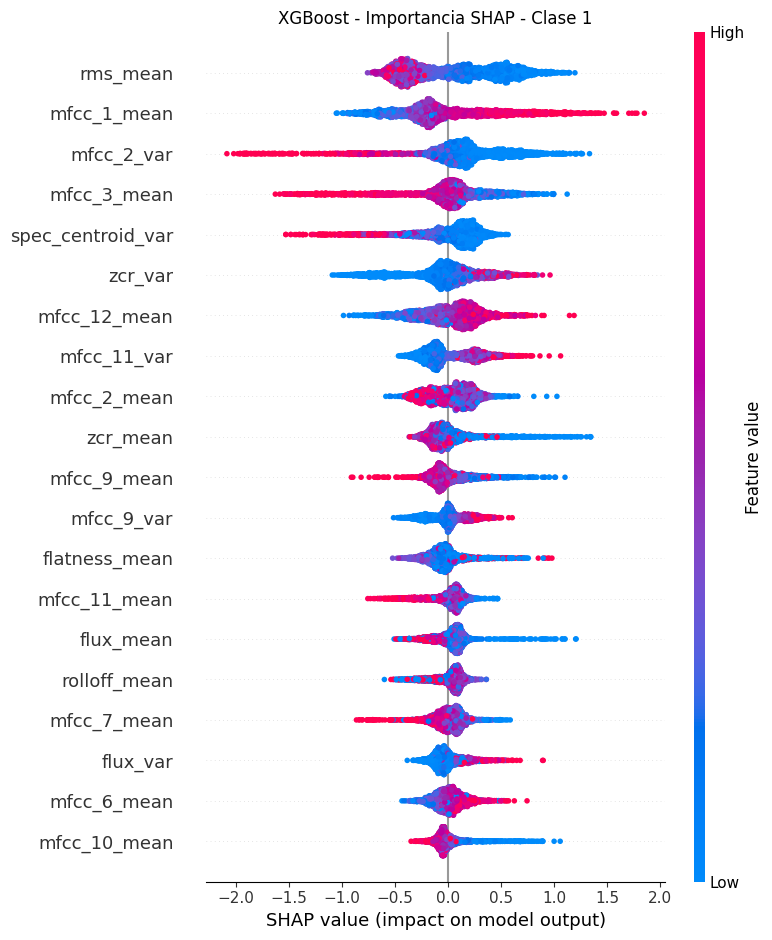

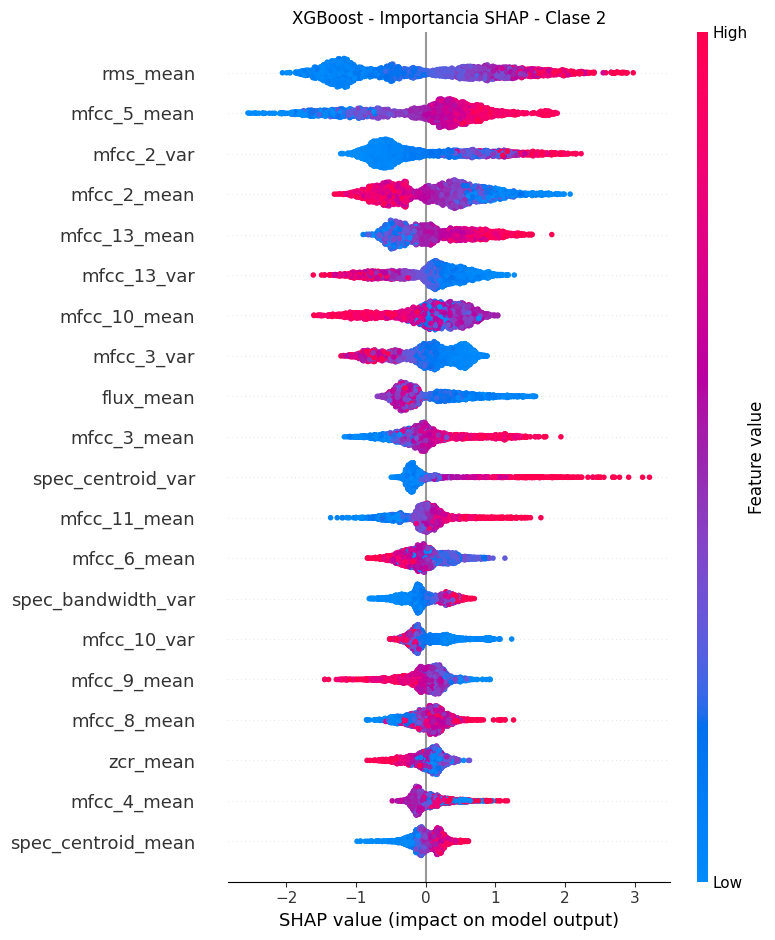

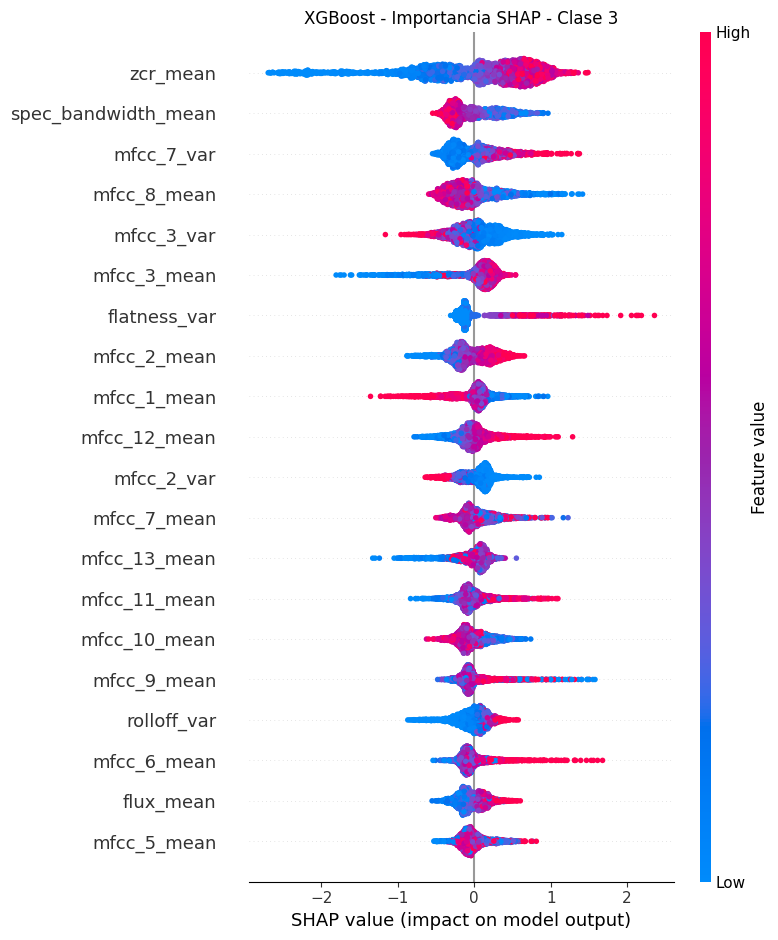

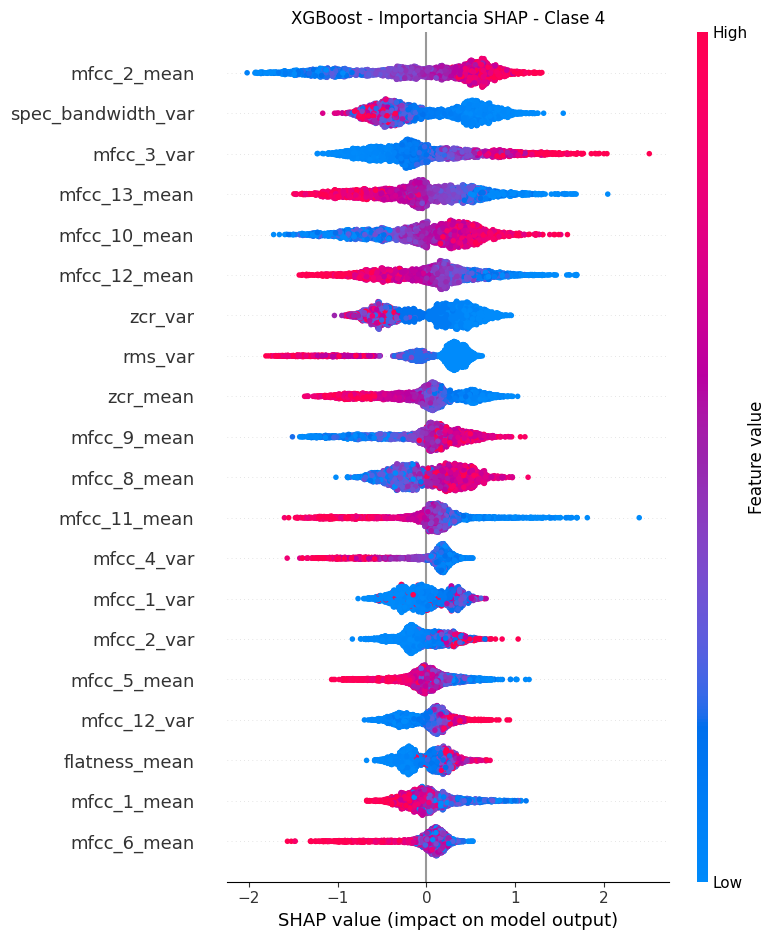

Calculando SHAP para Random 


100%|===================| 12145/12148 [50:19<00:00]        

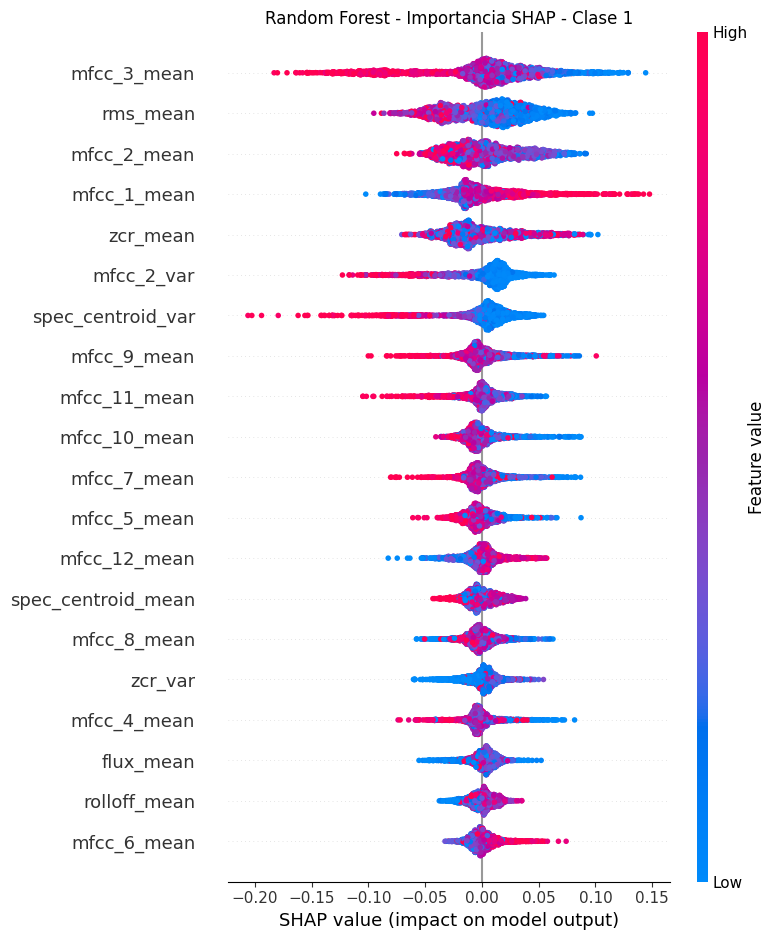

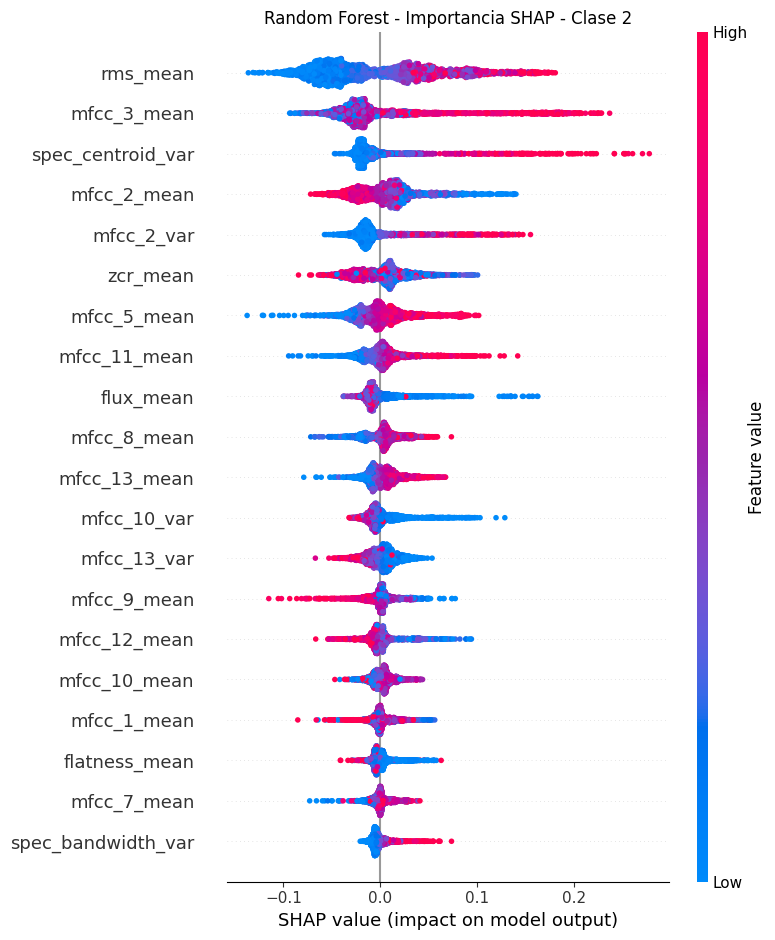

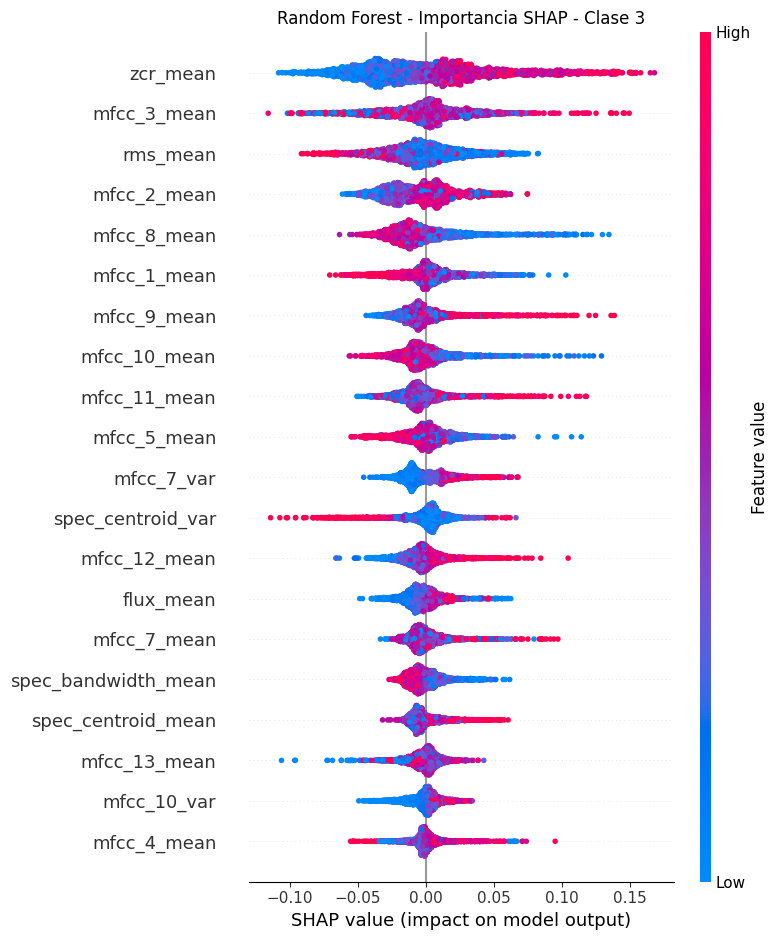

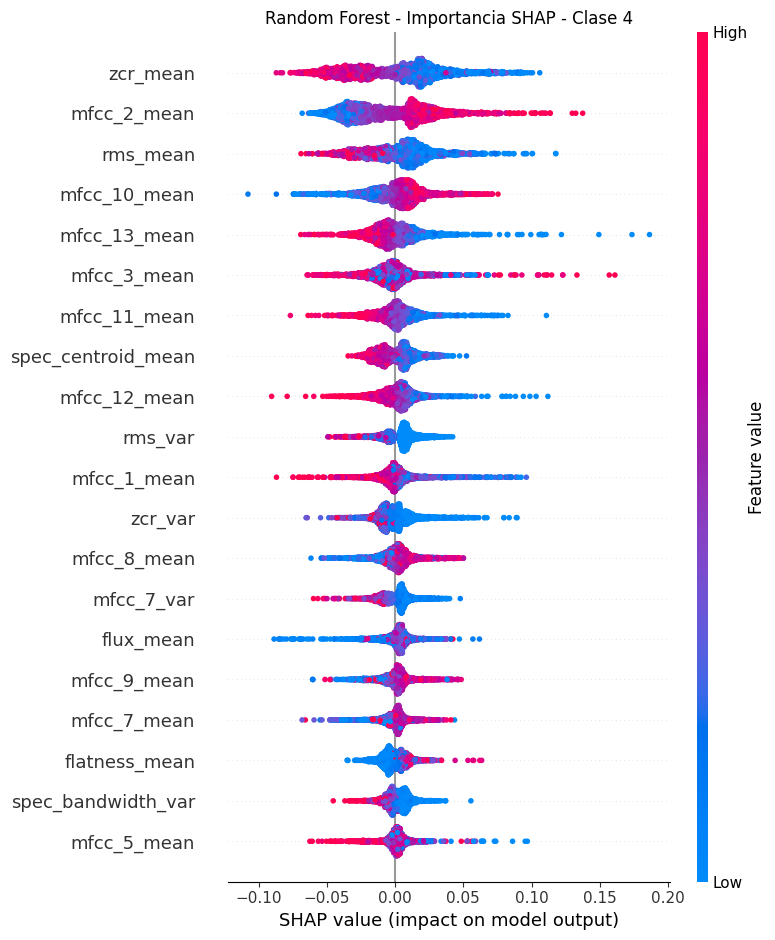

In [19]:
# XGBoost
print("Calculando SHAP para XGBoos")
explainer_xgb = shap.Explainer(models['XGBoost'], X_train)
shap_values_xgb = explainer_xgb(X_test)

for i in range(4):  # Clases 0, 1, 2
    plt.figure()
    shap.summary_plot(shap_values_xgb[:, :, i], X_test, show=False)
    plt.title(f"XGBoost - Importancia SHAP - Clase {i+1}")
    plt.tight_layout()
    plt.show()

# Random Fores
print("Calculando SHAP para Random ")
explainer_rf = shap.Explainer(models['Random Forest'], X_train)
shap_values_rf = explainer_rf(X_test)

for i in range(4):  # Clases 0, 1, 2
    plt.figure()
    shap.summary_plot(shap_values_rf[:, :, i], X_test, show=False)
    plt.title(f"Random Forest - Importancia SHAP - Clase {i+1}")
    plt.tight_layout()
    plt.show()
